In [1]:
import pandas as pd # data minipulation
import numpy as np
import matplotlib.pyplot as plt # visualization
import seaborn as sns
import statsmodels.api as sm # OLS regression
from sklearn.model_selection import train_test_split # train/test split, scaling, and eval metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("C:\\Users\\Micha\\OneDrive\\Documents\\HIT 216\\seer_crc_raw.csv") # import data set

In [3]:
# Rename columns
df.columns = [
    'age_group',        # age recode with <1 year olds and 90+
    'dx_year',          # year of diagnosis
    'race',             # race recode (W, B, AI, API)
    'stage',            # combined Summary Stage with Expanded Regional Codes (2004+)
    'survival_months'   # survival months
]

print('Renamed columns:', df.columns.tolist())
df.head()

Renamed columns: ['age_group', 'dx_year', 'race', 'stage', 'survival_months']


,age_group,dx_year,race,stage,survival_months
0,65-69 years,2014,Asian or Pacific Islander,Regional by both direct extension and lymph no...,0102
1,70-74 years,2011,White,Regional lymph nodes involved only,0134
2,45-49 years,2019,Asian or Pacific Islander,Regional lymph nodes involved only,0046
3,50-54 years,2017,Asian or Pacific Islander,Regional lymph nodes involved only,0066
4,90+ years,2015,White,Localized only,0000


In [4]:
# check for missing values across all columns
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values)
print()

# inspect unique values in 'race' (SEER uses 'Unknown' as a placeholder)
print('Unique values in race column:')
print(df['race'].value_counts(dropna=False))
print()

# inspect stage categories (some are uninformative for modeling)
print('Unique values in stage column:')
print(df['stage'].value_counts(dropna=False))

Missing values per column:
age_group          0
dx_year            0
race               0
stage              0
survival_months    0
dtype: int64

Unique values in race column:
race
White                            359433
Black                             54501
Asian or Pacific Islander         43081
Unknown                            5120
American Indian/Alaska Native      4354
Name: count, dtype: int64

Unique values in stage column:
stage
Localized only                                                  172579
Distant site(s)/node(s) involved                                100230
Regional by both direct extension and lymph node involvement     56155
Regional lymph nodes involved only                               54299
Regional by direct extension only                                52094
Unknown/unstaged/unspecified/DCO                                 31101
In situ                                                             31
Name: count, dtype: int64


In [5]:
# replace 'Unknown' string in race with NaN (true missing value)
df['race'] = df['race'].replace('Unknown', np.nan)

print('Before dropping missing values:', df.shape)
print()

# drop rows where survival_months is missing
df.dropna(subset=['survival_months'], inplace=True)
print('After dropping null survival_months:', df.shape)

# drop rows where race is missing
df.dropna(subset=['race'], inplace=True)
print('After dropping null race:', df.shape)

print()
print('Remaining missing values:')
print(df.isnull().sum())

Before dropping missing values: (466489, 5)

After dropping null survival_months: (466489, 5)
After dropping null race: (461369, 5)

Remaining missing values:
age_group          0
dx_year            0
race               0
stage              0
survival_months    0
dtype: int64


In [6]:
# convert survival_months to numeric; non-convertible values become NaN
df['survival_months'] = pd.to_numeric(df['survival_months'], errors='coerce')

# drop any rows where conversion failed and produced NaN
df.dropna(subset=['survival_months'], inplace=True)

# verify the data type is now float64
print('Updated data types:')
print(df.dtypes)
print()
print('Missing values after type conversion:')
print(df.isnull().sum())

Updated data types:
age_group              str
dx_year              int64
race                   str
stage                  str
survival_months    float64
dtype: object

Missing values after type conversion:
age_group          0
dx_year            0
race               0
stage              0
survival_months    0
dtype: int64


In [7]:
# convert all string columns to lowercase for consistency
string_cols = ['age_group', 'race', 'stage']

for col in string_cols:
    df[col] = df[col].str.lower()

print('Sample values after lowercasing:')
for col in string_cols:
    print(f'  {col}: {df[col].dropna().unique()[:3]}')

Sample values after lowercasing:
  age_group: <StringArray>
['65-69 years', '70-74 years', '45-49 years']
Length: 3, dtype: str
  race: <StringArray>
['asian or pacific islander', 'white', 'american indian/alaska native']
Length: 3, dtype: str
  stage: <StringArray>
['regional by both direct extension and lymph node involvement',
                           'regional lymph nodes involved only',
                                               'localized only']
Length: 3, dtype: str


In [8]:
# define symbols to remove from string columns
# note: '-' and '+' are intentionally kept; they are meaningful in age group
# labels and stage descriptions
symbols = [
    '!', '"', "'", '~', '@', '#', '$', '%', '^', '&',
    '*', '<', '>', '?', '/', '`', '|', '\\', '=',
    'https', 'http', 'ã©'
]

# apply symbol removal to each string column
for col in string_cols:
    for char in symbols:
        df[col] = df[col].str.replace(char, ' ', regex=False)
    # clean up extra whitespace caused by replacements
    df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)

print('Sample values after symbol removal:')
for col in string_cols:
    print(f'  {col}: {df[col].dropna().unique()[:3]}')

Sample values after symbol removal:
  age_group: <StringArray>
['65-69 years', '70-74 years', '45-49 years']
Length: 3, dtype: str
  race: <StringArray>
['asian or pacific islander', 'white', 'american indian alaska native']
Length: 3, dtype: str
  stage: <StringArray>
['regional by both direct extension and lymph node involvement',
                           'regional lymph nodes involved only',
                                               'localized only']
Length: 3, dtype: str


In [9]:
# drop rows where stage is unknown/unstaged; no useful predictor information
before = len(df)
df = df[df['stage'] != 'unknown unstaged unspecified dco']
print(f'Dropped unknown/unstaged stage rows: {before - len(df):,}')

# drop rows where stage is in situ
before = len(df)
df = df[df['stage'] != 'in situ']
print(f'Dropped in situ stage rows: {before - len(df):,}')

print()
print('Remaining stage categories:')
print(df['stage'].value_counts())

Dropped unknown/unstaged stage rows: 24,650
Dropped in situ stage rows: 29

Remaining stage categories:
stage
localized only                                                  170207
distant site(s) node(s) involved                                 99771
regional by both direct extension and lymph node involvement     55874
regional lymph nodes involved only                               53986
regional by direct extension only                                51762
Name: count, dtype: int64


In [10]:
# report duplicate count for transparency; not dropping as each case represents a different patient
duplicate_count = df.duplicated().sum()
print(f'Rows that appear identical across all 5 columns: {duplicate_count:,}')
print()
print('Decision: Duplicates retained as these likely represent different patients')
print('with coincidentally identical demographic and clinical profiles.')
print()
print('Rows retained:', f'{df.shape[0]:,}')

Rows that appear identical across all 5 columns: 340,148

Decision: Duplicates retained as these likely represent different patients
with coincidentally identical demographic and clinical profiles.

Rows retained: 431,600


In [11]:
# validate: survival_months should be >= 0
# note: 0 months is a valid value; indicates patient death during same month
# as diagnosis. these represent the worst outcomes and are important for regression
assert df['survival_months'].min() >= 0, 'Negative survival months found!'
print('survival_months >= 0: PASSED')

# validate dx_year within the filtered range (2010–2015)
# note: validation runs after the year filter is applied below,
# so we assert the post-filter range here
assert df['dx_year'].between(2000, 2025).all(), 'Unexpected diagnosis year found!'
print('dx_year in valid range: PASSED')

# validate: expected number of columns
assert df.shape[1] == 5, 'Unexpected number of columns!'
print('Column count = 5: PASSED')

# validate: no missing values remain (note: raw data DID contain missing values;
# they were removed in cells 4–5 above; this confirms successful cleaning)
assert df.isnull().sum().sum() == 0, 'Unexpected missing values found!'
print('No missing values remaining (post-preprocessing): PASSED')

# validate: only expected stage categories remain
expected_stages = {
    'localized only',
    'distant site(s) node(s) involved',
    'regional by both direct extension and lymph node involvement',
    'regional lymph nodes involved only',
    'regional by direct extension only'
}
assert set(df['stage'].unique()) == expected_stages, 'Unexpected stage categories found!'
print('Stage categories valid: PASSED')

print()
print('Pre-filter dataset shape:', df.shape)
df.head()

survival_months >= 0: PASSED
dx_year in valid range: PASSED
Column count = 5: PASSED
No missing values remaining: PASSED
Stage categories valid: PASSED

Pre-filter dataset shape: (431600, 5)


,age_group,dx_year,race,stage,survival_months
0,65-69 years,2014,asian or pacific islander,regional by both direct extension and lymph no...,102.0
1,70-74 years,2011,white,regional lymph nodes involved only,134.0
2,45-49 years,2019,asian or pacific islander,regional lymph nodes involved only,46.0
3,50-54 years,2017,asian or pacific islander,regional lymph nodes involved only,66.0
4,90+ years,2015,white,localized only,0.0


In [12]:
# ── Step 1: Filter to Diagnosis Years 2010–2015 ─────────────────────────────
# Narrowing the year range reduces right-censoring bias. Patients diagnosed
# in 2015 or earlier have had at least 8–10 years of potential follow-up,
# making survival_months more complete and comparable across the cohort
df = df[df['dx_year'].between(2010, 2015)].copy()
print(f'Rows after year filter (2010–2015): {len(df):,}')


# ── Step 2: Collapse Age Groups into Two Binary Columns ──────────────────────
# The original data has 13+ narrow age bands, which produce many correlated
# dummy variables and inflate multicollinearity. We consolidate into two
# clinically meaningful groups:
#   age_under_85 = patients aged 0–84  (1 = yes, 0 = no)
#   age_85_plus  = patients aged 85+   (1 = yes, 0 = no)
# columns are mutually exclusive and exhaustive

# Define which age group labels fall into the 85+ category
age_85_plus_groups = ['85-89 years', '90+ years']

df['age_85_plus']  = df['age_group'].isin(age_85_plus_groups).astype(int)
df['age_under_85'] = (1 - df['age_85_plus'])  # complement: every row not 85+
# Drop age_under_85; keeping both causes perfect multicollinearity
# age_under_85 becomes the implicit reference category 
df.drop(columns=['age_under_85'], inplace=True)

print()
print('Age column distribution:')
print(f'  age_85_plus (85+):    {df["age_85_plus"].sum():,}')
print(f'  age_under_85 (ref):   {(df["age_85_plus"] == 0).sum():,}')

# Drop the original age_group column; replaced by the two binary columns
df.drop(columns=['age_group'], inplace=True)

# Reset index after all row removals and column changes
df.reset_index(drop=True, inplace=True)

# Save the cleaned, filtered dataset
df.to_csv('seer_crc_clean_final.csv', index=False)
print()
print('Cleaned + filtered dataset saved to: seer_crc_clean_final.csv')
print('Final shape:', df.shape)

Rows after year filter (2010–2015): 198,346

Age column distribution:
  age_85_plus (85+):    20,579
  age_under_85 (ref):   177,767

Cleaned + filtered dataset saved to: seer_crc_clean_final.csv
Final shape: (198346, 5)


In [13]:
# ── Final Verification Before EDA ────────────────────────────────────────────
print('FINAL VERIFICATION BEFORE EDA')

# 1. Shape
print(f'\nShape: {df.shape}')

# 2. Column names
print(f'\nColumns: {df.columns.tolist()}')

# 3. Data types
print(f'\nData types:')
print(df.dtypes)

# 4. Missing values
print(f'\nMissing values:')
print(df.isnull().sum())

# 5. Stage categories
print(f'\nStage categories:')
print(df['stage'].value_counts())

# 6. Race categories
print(f'\nRace categories:')
print(df['race'].value_counts())

# 7. Age binary column 
print(f'\nAge binary column:')
print(df[['age_85_plus']].sum())

# 8. Survival months range
print(f'\nSurvival months range: {df["survival_months"].min()} to {df["survival_months"].max()}')
print(f'Mean: {df["survival_months"].mean():.2f}')

# 9. Diagnosis year range 
print(f'\nDiagnosis year range: {df["dx_year"].min()} to {df["dx_year"].max()}')
assert df['dx_year'].between(2010, 2015).all(), 'Year filter failed!'
print('Year range (2010–2015): PASSED')

print('\nVERIFICATION COMPLETE')

FINAL VERIFICATION BEFORE EDA

Shape: (198346, 5)

Columns: ['dx_year', 'race', 'stage', 'survival_months', 'age_85_plus']

Data types:
dx_year              int64
race                   str
stage                  str
survival_months    float64
age_85_plus          int64
dtype: object

Missing values:
dx_year            0
race               0
stage              0
survival_months    0
age_85_plus        0
dtype: int64

Stage categories:
stage
localized only                                                  82373
distant site(s) node(s) involved                                43718
regional lymph nodes involved only                              25757
regional by both direct extension and lymph node involvement    23342
regional by direct extension only                               23156
Name: count, dtype: int64

Race categories:
race
white                            156241
black                             23012
asian or pacific islander         17389
american indian alaska native      1

In [14]:
# ── Descriptive Statistics ───────────────────────────────────────────────────

# Numerical columns 
print('\n── Numerical Columns ──')
print(df[['survival_months', 'dx_year']].describe())

# Manual stats for survival_months
print('\n── Survival Months ──')
print(f'Mean:    {df["survival_months"].mean():.2f}')
print(f'Median:  {df["survival_months"].median():.2f}')
print(f'Mode:    {df["survival_months"].mode()[0]:.2f}')
print(f'Range:   {df["survival_months"].min():.2f} to {df["survival_months"].max():.2f}')
print(f'Std Dev: {df["survival_months"].std():.2f}')

# Manual stats for dx_year
print('\n── Diagnosis Year (filtered: 2010–2015) ──')
print(f'Mean:    {df["dx_year"].mean():.2f}')
print(f'Median:  {df["dx_year"].median():.2f}')
print(f'Mode:    {df["dx_year"].mode()[0]}')
print(f'Range:   {df["dx_year"].min()} to {df["dx_year"].max()}')

# Categorical columns 
print('\n── Categorical Columns ──')
for col in ['race', 'stage']:
    print(f'\n{col.upper()}:')
    print(f'  Mode:              {df[col].mode()[0]}')
    print(f'  Unique categories: {df[col].nunique()}')
    print(df[col].value_counts())

# Age binary summary
print('\n── Age Groups (Collapsed) ──')
age_under_85_count = (df['age_85_plus'] == 0).sum()
age_under_85_pct   = age_under_85_count / len(df) * 100
print(f'age_under_85 (0–84): {age_under_85_count:,} ({age_under_85_pct:.1f}%)')
print(f'age_85_plus  (85+):  {df["age_85_plus"].sum():,} ({df["age_85_plus"].mean()*100:.1f}%)')


── Numerical Columns ──
       survival_months        dx_year
count    198346.000000  198346.000000
mean         68.422549    2012.509252
std          49.192080       1.711286
min           0.000000    2010.000000
25%          19.000000    2011.000000
50%          73.000000    2013.000000
75%         111.000000    2014.000000
max         155.000000    2015.000000

── Survival Months ──
Mean:    68.42
Median:  73.00
Mode:    0.00
Range:   0.00 to 155.00
Std Dev: 49.19

── Diagnosis Year (filtered: 2010–2015) ──
Mean:    2012.51
Median:  2013.00
Mode:    2014
Range:   2010 to 2015

── Categorical Columns ──

RACE:
  Mode:              white
  Unique categories: 4
race
white                            156241
black                             23012
asian or pacific islander         17389
american indian alaska native      1704
Name: count, dtype: int64

STAGE:
  Mode:              localized only
  Unique categories: 5
stage
localized only                                                  8

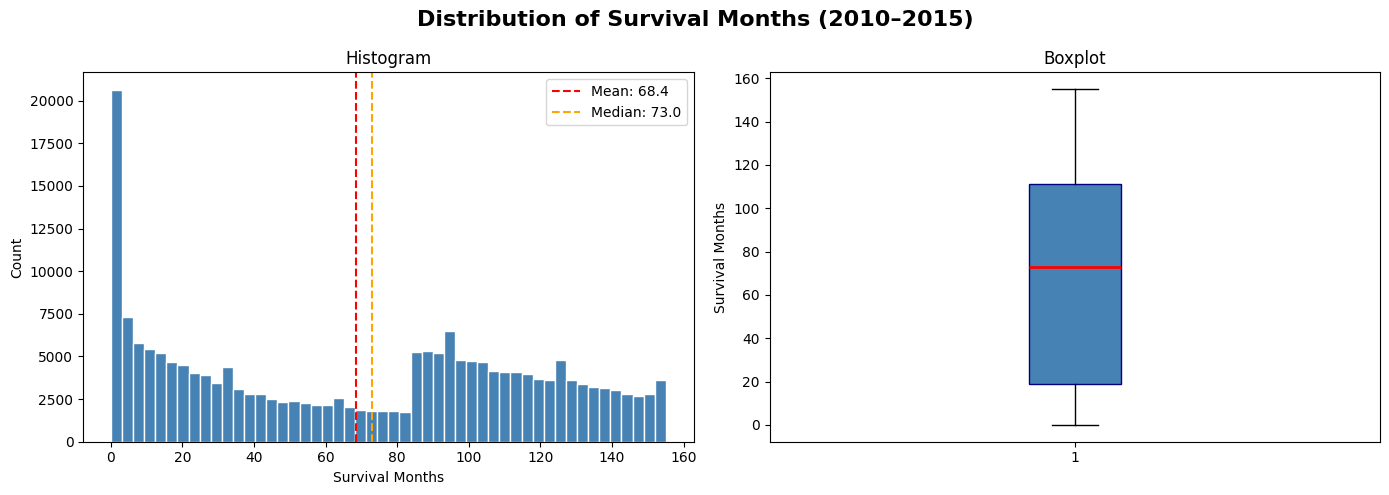

In [15]:
# ── Distribution of Survival Months (2010–2015 cohort) ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Survival Months (2010–2015)', fontsize=16, fontweight='bold')

# Histogram
axes[0].hist(df['survival_months'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Survival Months')
axes[0].set_ylabel('Count')
axes[0].axvline(df['survival_months'].mean(), color='red', linestyle='--', label=f'Mean: {df["survival_months"].mean():.1f}')
axes[0].axvline(df['survival_months'].median(), color='orange', linestyle='--', label=f'Median: {df["survival_months"].median():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['survival_months'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot')
axes[1].set_ylabel('Survival Months')

plt.tight_layout()
plt.show()

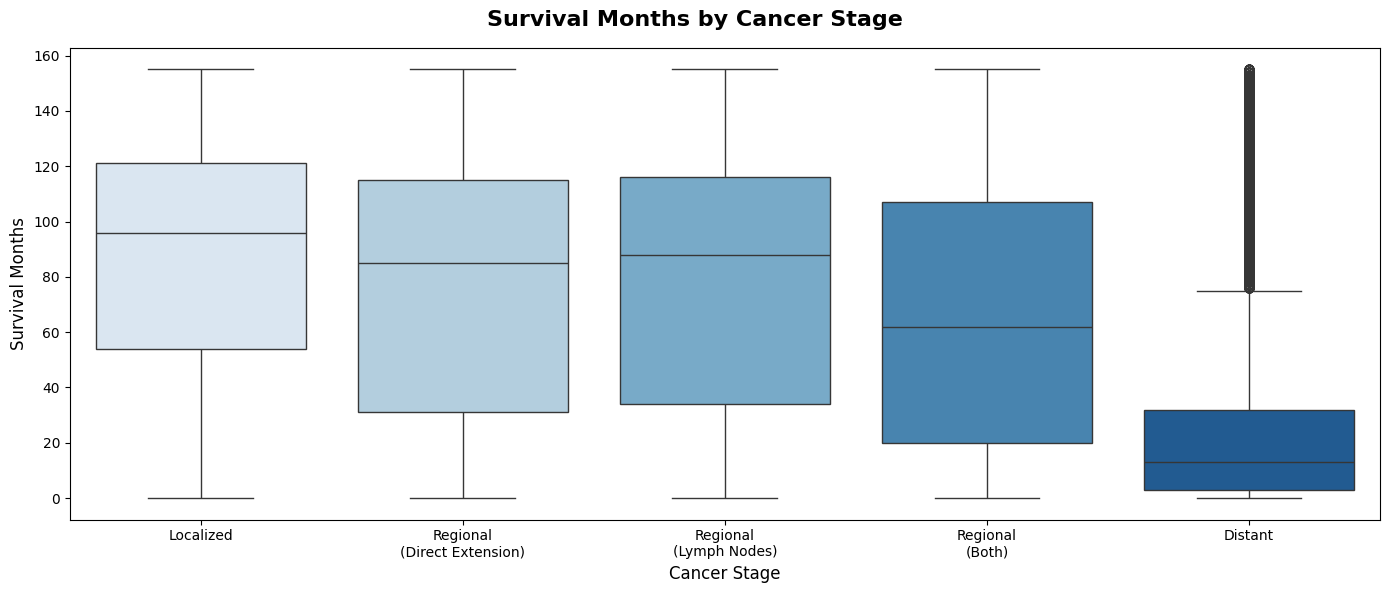

In [16]:
# ── Survival Months by Stage ─────────────────────────────────────────────────

stage_order = [
    'localized only',
    'regional by direct extension only',
    'regional lymph nodes involved only',
    'regional by both direct extension and lymph node involvement',
    'distant site(s) node(s) involved'
]

stage_labels = [
    'Localized',
    'Regional\n(Direct Extension)',
    'Regional\n(Lymph Nodes)',
    'Regional\n(Both)',
    'Distant'
]

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Survival Months by Cancer Stage', fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='stage', y='survival_months', order=stage_order,
            hue='stage', hue_order=stage_order, palette='Blues',
            legend=False, ax=ax)

ax.set_xlabel('Cancer Stage', fontsize=12)
ax.set_ylabel('Survival Months', fontsize=12)
ax.set_xticks(range(len(stage_labels)))
ax.set_xticklabels(stage_labels, fontsize=10)

plt.tight_layout()
plt.show()

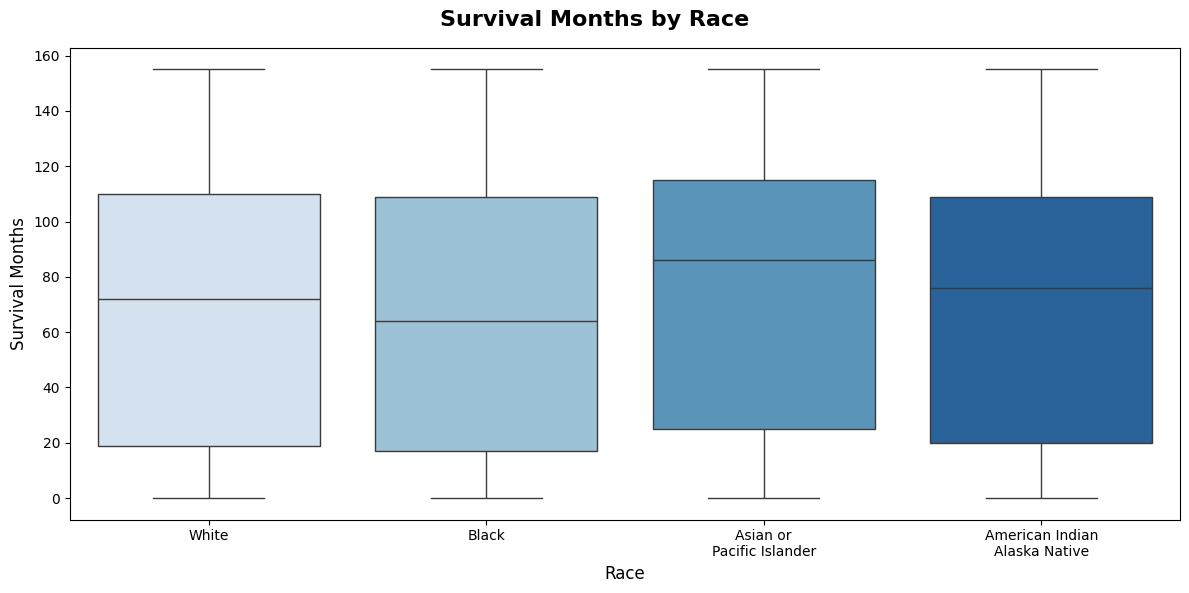

In [17]:
# ── Survival Months by Race ──────────────────────────────────────────────────

race_order = [
    'white',
    'black',
    'asian or pacific islander',
    'american indian alaska native'
]

race_labels = [
    'White',
    'Black',
    'Asian or\nPacific Islander',
    'American Indian\nAlaska Native'
]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Survival Months by Race', fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='race', y='survival_months', order=race_order,
            hue='race', hue_order=race_order, palette='Blues',
            legend=False, ax=ax)

ax.set_xlabel('Race', fontsize=12)
ax.set_ylabel('Survival Months', fontsize=12)
ax.set_xticks(range(len(race_labels)))
ax.set_xticklabels(race_labels, fontsize=10)

plt.tight_layout()
plt.show()

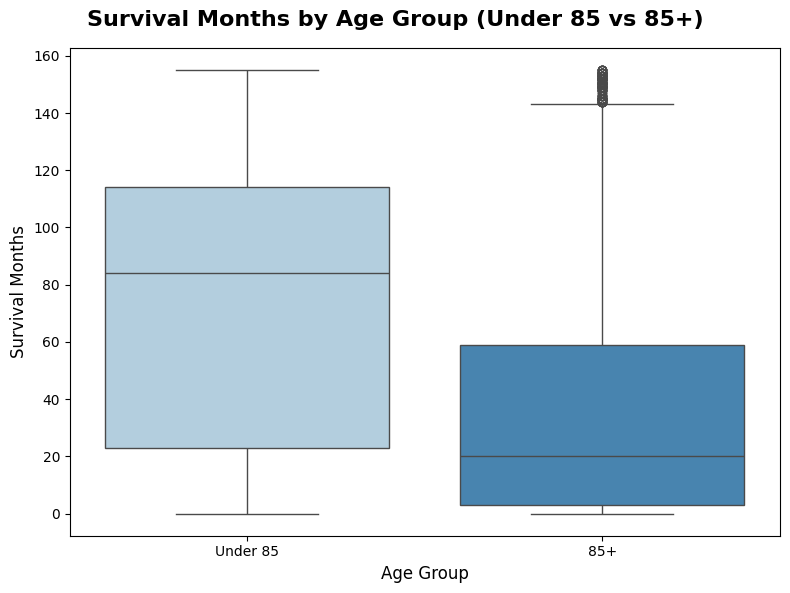

In [18]:
# ── Survival Months by Age Group  ───────────────
# The original granular age bands have been collapsed into two clinical groups.
# This plot compares survival distributions between those two groups.

# Create a readable label column for plotting
df['age_group_label'] = df['age_85_plus'].map({0: 'Under 85', 1: '85+'})

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Survival Months by Age Group (Under 85 vs 85+)',
             fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='age_group_label', y='survival_months',
            order=['Under 85', '85+'],
            hue='age_group_label', hue_order=['Under 85', '85+'],
            palette='Blues', legend=False, ax=ax)

ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Survival Months', fontsize=12)

plt.tight_layout()
plt.show()

# Drop the temporary label column; only needed for this plot
df.drop(columns=['age_group_label'], inplace=True)

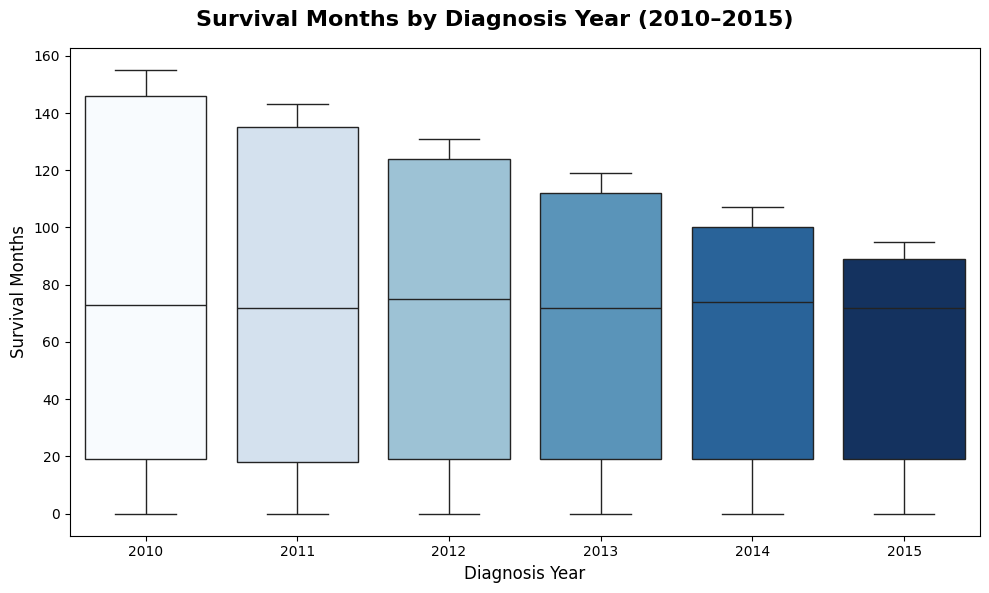

In [19]:
# ── Survival Months by Diagnosis Year (2010–2015) ────────────────────────────
# With year range narrowed, plot shows variation across a 6-year window
# remaining downward trend in recent years reflects residual right-censoring

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Survival Months by Diagnosis Year (2010–2015)',
             fontsize=16, fontweight='bold')

year_order = sorted(df['dx_year'].unique())

sns.boxplot(data=df, x='dx_year', y='survival_months', order=year_order,
            hue='dx_year', hue_order=year_order, palette='Blues',
            legend=False, ax=ax)

ax.set_xlabel('Diagnosis Year', fontsize=12)
ax.set_ylabel('Survival Months', fontsize=12)
ax.set_xticks(range(len(year_order)))
ax.set_xticklabels(year_order, fontsize=10)

plt.tight_layout()
plt.show()

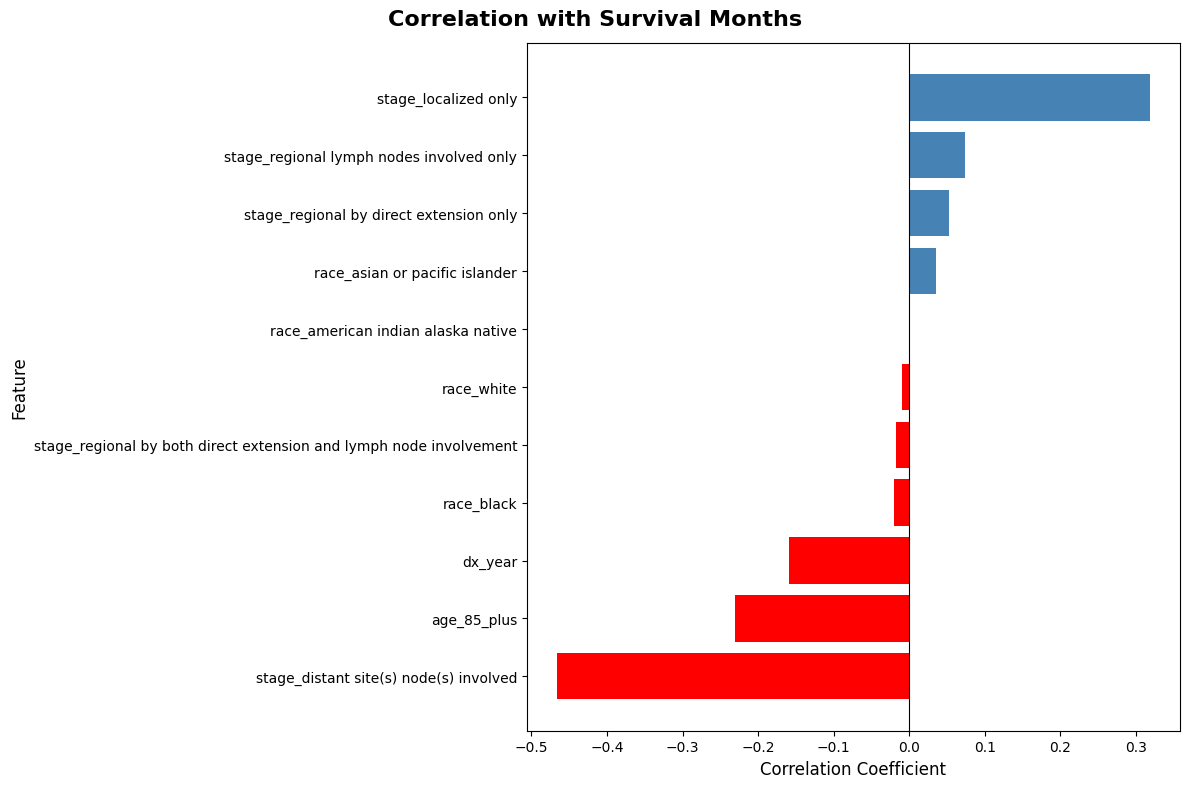


Top positive correlations with survival_months:
race_american indian alaska native          0.000353
race_asian or pacific islander              0.035985
stage_regional by direct extension only     0.052367
stage_regional lymph nodes involved only    0.074290
stage_localized only                        0.319249
Name: survival_months, dtype: float64

Top negative correlations with survival_months:
stage_distant site(s) node(s) involved                               -0.466706
age_85_plus                                                          -0.231178
dx_year                                                              -0.159169
race_black                                                           -0.019543
stage_regional by both direct extension and lymph node involvement   -0.017517
Name: survival_months, dtype: float64


In [20]:
# ── Correlation Analysis ─────────────────────────────────────────────────────
# one-hot encode race and stage for correlation purposes; not the
# final model encoding. two age binary columns are already numeric

df_encoded_corr = pd.get_dummies(df, columns=['race', 'stage'], drop_first=False)

# Compute correlation of all columns with survival_months
correlations = df_encoded_corr.corr()['survival_months'].drop('survival_months').sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Correlation with Survival Months', fontsize=16, fontweight='bold')

colors = ['red' if c < 0 else 'steelblue' for c in correlations]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.show()

print('\nTop positive correlations with survival_months:')
print(correlations.tail(5))
print('\nTop negative correlations with survival_months:')
print(correlations.head(5))

# ── Methodological Note on Diagnosis Year ───────────────────────────────────
# The negative correlation for dx_year does NOT indicate worsening survival
# outcomes over time. It is a right-censoring artifact: patients diagnosed
# in later years (closer to the 2015 data extract) had less follow-up time
# recorded, producing artificially shorter observed survival durations.
# Median survival remains stable across all years (~70-75 months), confirming
# this is a data collection bias rather than a clinical trend.
print('\nNote: dx_year negative correlation is a right-censoring artifact (shorter follow-up for later years).')

In [21]:
# ── Step 3 & 4: Preprocessing — Dummy Encode Categorical Variables ───────────
# age_group already replaced by two binary columns (age_under_85,
# age_85_plus) during cleaning; only need to encode race and stage here
#
# drop_first=True drops one category per variable to avoid the dummy variable
# trap (perfect multicollinearity between one-hot columns)

# note: the 5 original variables (dx_year, age_85_plus, race, stage, survival_months)
# expand into 9 model predictors after dummy encoding:
#   dx_year (1), age_85_plus (1), race (3 dummies), stage (4 dummies)
# survival_months is the target (y), not a predictor
df_model = pd.get_dummies(df, columns=['race', 'stage'], drop_first=True)

# Convert boolean dummy columns to integers (required by statsmodels)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print('Shape after encoding:', df_model.shape)
print()
print('Columns after encoding:')
print(df_model.columns.tolist())
print()
print('Dtypes:')
print(df_model.dtypes)

Shape after encoding: (198346, 10)

Columns after encoding:
['dx_year', 'survival_months', 'age_85_plus', 'race_asian or pacific islander', 'race_black', 'race_white', 'stage_localized only', 'stage_regional by both direct extension and lymph node involvement', 'stage_regional by direct extension only', 'stage_regional lymph nodes involved only']

Dtypes:
dx_year                                                                 int64
survival_months                                                       float64
age_85_plus                                                             int64
race_asian or pacific islander                                          int64
race_black                                                              int64
race_white                                                              int64
stage_localized only                                                    int64
stage_regional by both direct extension and lymph node involvement      int64
stage_regional by 

In [22]:
# ── Split Data into Training and Test Sets ───────────────────────────────────

# Define features (X) and target variable (y)
X = df_model.drop(columns=['survival_months'])
y = df_model['survival_months']

# Split 80% training, 20% testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)

Training set size: (158676, 9)
Test set size:     (39670, 9)


In [23]:
# ── Step 5: Normalize Features with StandardScaler ───────────────────────────
# StandardScaler transforms each feature to have mean=0 and std=1 (z-score).
# This is important because dx_year and survival_months
# are on very different scales. Normalizing puts all predictors on a
# common scale, stabilizes coefficient estimates, and reduces multicollinearity
# contributions from scale differences
#
# IMPORTANT — data leakage prevention:
# scaler is fit on training data ONLY, then applied (transform only) to test set.
# Fitting on the full dataset before splitting would leak test-set statistics
# into the training process and produce over-optimistic evaluation metrics.

scaler = StandardScaler()

# Fit on training data; transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames for statsmodels
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print('Scaling complete.')
print('X_train_scaled shape:', X_train_scaled.shape)
print()
print('Sample means after scaling (should be ~0):')
print(X_train_scaled.mean().round(6))
print()
print('Sample std devs after scaling (should be ~1):')
print(X_train_scaled.std().round(6))

Scaling complete.
X_train_scaled shape: (158676, 9)

Sample means after scaling (should be ~0):
dx_year                                                               0.0
age_85_plus                                                          -0.0
race_asian or pacific islander                                        0.0
race_black                                                           -0.0
race_white                                                            0.0
stage_localized only                                                 -0.0
stage_regional by both direct extension and lymph node involvement    0.0
stage_regional by direct extension only                              -0.0
stage_regional lymph nodes involved only                              0.0
dtype: float64

Sample std devs after scaling (should be ~1):
dx_year                                                               1.000003
age_85_plus                                                           1.000003
race_asian or paci

In [24]:
# ── Multiple Linear Regression with Statsmodels ──────────────────────────────
# use the scaled (normalized) features for fitting.
# add_constant adds the intercept term required by statsmodels OLS

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm  = sm.add_constant(X_test_scaled)

# Fit OLS model on training data
model = sm.OLS(y_train, X_train_sm).fit()

# Print full regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        survival_months   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     8259.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        16:09:19   Log-Likelihood:            -8.1285e+05
No. Observations:              158676   AIC:                         1.626e+06
Df Residuals:                  158666   BIC:                         1.626e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [25]:
# ── Model Evaluation on Test Set ─────────────────────────────────────────────

# Generate predictions using the scaled test set
y_pred = model.predict(X_test_sm)

# Evaluation metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('='*50)
print('MODEL EVALUATION — TEST SET')
print('='*50)
print(f'R-squared:  {r2:.4f}')
print(f'MAE:        {mae:.2f} months')
print(f'RMSE:       {rmse:.2f} months')

MODEL EVALUATION — TEST SET
R-squared:  0.3114
MAE:        34.10 months
RMSE:       40.80 months


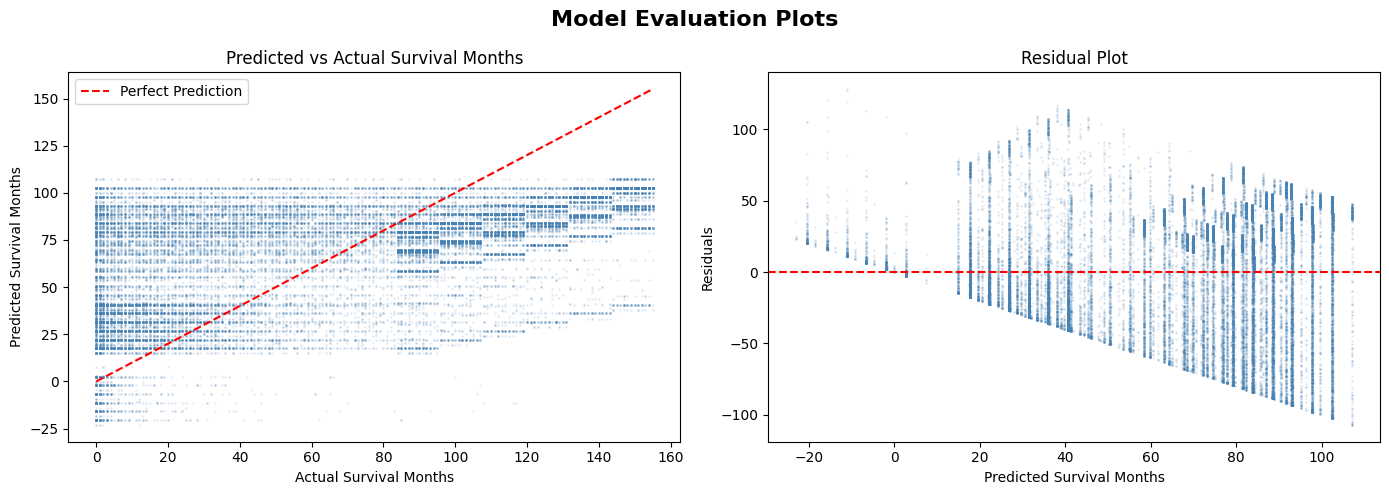

In [26]:
# ── Post-Model Visualizations ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation Plots', fontsize=16, fontweight='bold')

# Plot 1 — Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.1, color='steelblue', s=1)
axes[0].plot([0, 155], [0, 155], color='red', linestyle='--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title('Predicted vs Actual Survival Months')
axes[0].set_xlabel('Actual Survival Months')
axes[0].set_ylabel('Predicted Survival Months')
axes[0].legend()

# Plot 2 — Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.1, color='steelblue', s=1)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Survival Months')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

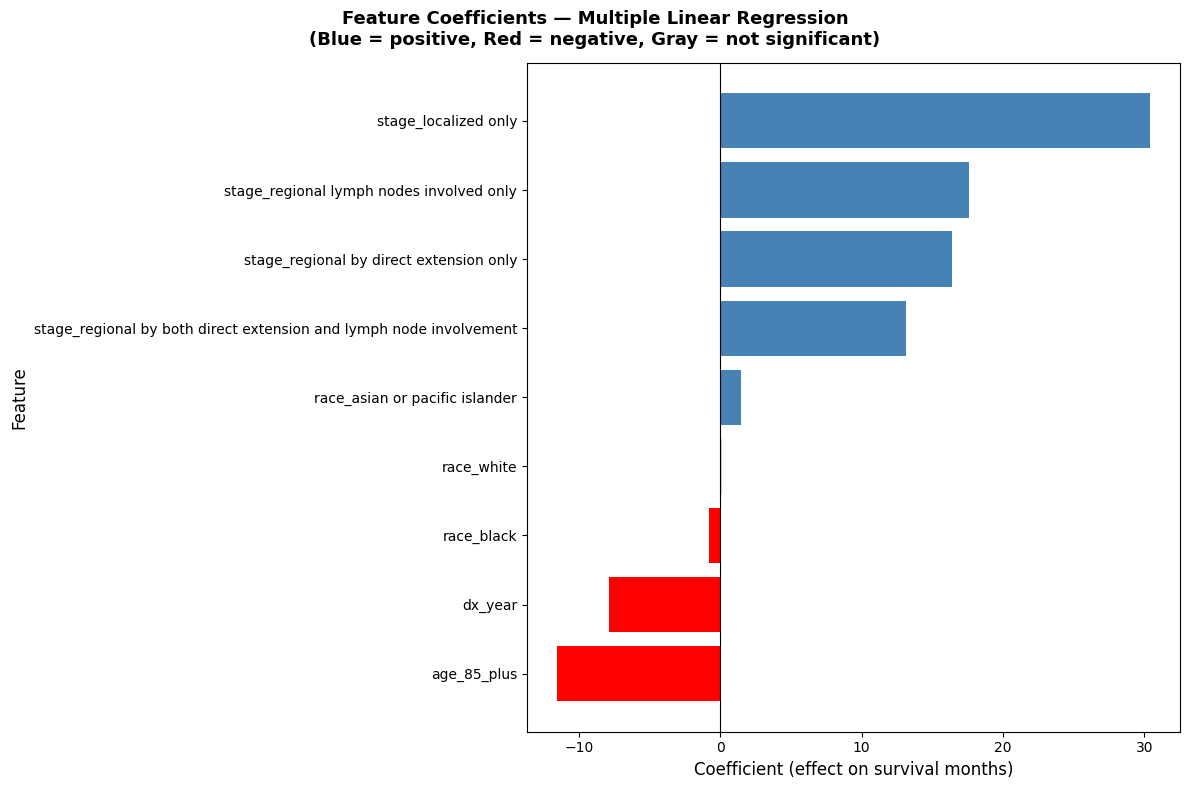

FEATURE COEFFICIENTS SUMMARY
Feature                                                     Coef    p-value   Sig
----------------------------------------------------------------------
stage_localized only                                       30.42     0.0000   ***
stage_regional lymph nodes involved only                   17.62     0.0000   ***
stage_regional by direct extension only                    16.37     0.0000   ***
stage_regional by both direct extension and lymph node involvement    13.14     0.0000   ***
race_asian or pacific islander                              1.43     0.0000   ***
race_white                                                  0.10     0.8335      
race_black                                                 -0.78     0.0330     *
dx_year                                                    -7.88     0.0000   ***
age_85_plus                                               -11.59     0.0000   ***


In [27]:
# ── Feature Importance ────────────────────────────────────────────────────────

# Extract coefficients from the model (excluding the constant)
coef = model.params.drop('const')
pvalues = model.pvalues.drop('const')

# Create a dataframe of coefficients and p-values
coef_df = pd.DataFrame({
    'coefficient': coef,
    'p_value': pvalues
}).sort_values('coefficient')

# Mark significant vs non-significant predictors
coef_df['significant'] = coef_df['p_value'] < 0.05
coef_df['color'] = coef_df.apply(
    lambda row: 'steelblue' if row['coefficient'] > 0 and row['significant']
    else 'red' if row['coefficient'] < 0 and row['significant']
    else 'lightgray', axis=1
)

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Feature Coefficients — Multiple Linear Regression\n(Blue = positive, Red = negative, Gray = not significant)',
             fontsize=13, fontweight='bold')

ax.barh(coef_df.index, coef_df['coefficient'], color=coef_df['color'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (effect on survival months)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary table
print('='*70)
print('FEATURE COEFFICIENTS SUMMARY')
print('='*70)
print(f'{"Feature":<55} {"Coef":>8} {"p-value":>10} {"Sig":>5}')
print('-'*70)
for idx, row in coef_df.sort_values('coefficient', ascending=False).iterrows():
    sig = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*' if row['p_value'] < 0.05 else ''
    print(f'{idx:<55} {row["coefficient"]:>8.2f} {row["p_value"]:>10.4f} {sig:>5}')